Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


Dataset

In [ ]:
claim_h = pd.read_csv('/content/drive/MyDrive/Classroom/claims_history.csv')
claim_h

,claim_id,payer_id,payer_type,visit_type,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,is_in_network,days_to_submit,missing_documentation_flag,eligibility_verified,referral_required,referral_present,split,service_month,is_denied,denial_reason
0,HCLM-00001,P008,Medicaid MCO,Outpatient,4311.44,1404.82,2,5,0,0,1,13,0,1,0,0,train,2024-06,1,Payer policy or medical necessity issue
1,HCLM-00002,P001,Commercial,Inpatient,10420.64,6065.91,6,8,1,1,0,19,0,1,1,1,train,2024-06,0,NaN
2,HCLM-00003,P010,BCBS,Outpatient,38369.33,20712.61,5,5,0,0,0,50,1,1,0,0,train,2024-02,1,Documentation incomplete or missing
3,HCLM-00004,P005,Medicare Advantage,Outpatient,6268.92,2306.49,6,3,1,1,1,7,0,1,1,1,validation,2024-09,0,NaN
4,HCLM-00005,P008,Medicaid MCO,Emergency,3986.26,1247.93,8,7,0,1,1,17,0,0,1,1,validation,2024-09,1,Patient eligibility could not be verified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,HCLM-03196,P006,Medicare Advantage,Outpatient,2017.98,829.70,4,5,0,0,1,25,0,1,1,1,train,2024-04,0,NaN
3196,HCLM-03197,P012,Medicaid MCO,Outpatient,9568.89,3281.23,3,2,0,0,1,17,1,1,0,1,train,2024-07,0,NaN
3197,HCLM-03198,P005,Medicare Advantage,Emergency,6406.36,2354.99,4,5,0,0,1,29,0,1,1,1,train,2024-03,0,NaN
3198,HCLM-03199,P012,Medicaid MCO,Outpatient,4296.24,1498.49,3,4,0,0,0,15,0,1,1,0,train,2024-04,0,NaN


In [ ]:
# Returns the count of duplicate payer_ids (excluding the first occurrence)
duplicate_count = claim_h['payer_id'].duplicated().sum()
print(f"Total duplicate rows in payer_id: {duplicate_count}")

Total duplicate rows in payer_id: 3188


In [ ]:
current_claims = pd.read_csv('/content/drive/MyDrive/Classroom/current_claims.csv')
current_claims

,claim_id,payer_id,payer_type,visit_type,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,is_in_network,days_to_submit,missing_documentation_flag,eligibility_verified,referral_required,referral_present,service_month
0,CCLM-00001,P004,Commercial,Emergency,2617.41,1120.76,4,5,0,0,0,14,0,1,0,0,2025-01
1,CCLM-00002,P003,Commercial,Outpatient,3060.56,1961.11,2,4,1,1,1,32,0,1,0,0,2025-02
2,CCLM-00003,P006,Medicare Advantage,Outpatient,11345.61,4650.61,3,5,0,0,1,10,0,0,0,0,2025-01
3,CCLM-00004,P003,Commercial,Inpatient,47634.66,23640.30,5,8,1,1,0,15,0,1,0,1,2025-02
4,CCLM-00005,P008,Medicaid MCO,Outpatient,2453.93,793.59,2,1,0,0,1,29,0,1,0,0,2025-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CCLM-00496,P005,Medicare Advantage,Observation,3869.97,1321.77,2,2,0,0,1,27,0,1,0,0,2025-01
496,CCLM-00497,P001,Commercial,Observation,3740.88,2057.47,2,5,0,0,0,4,0,0,0,0,2025-02
497,CCLM-00498,P007,Medicaid MCO,Emergency,9144.16,3570.37,4,6,0,1,1,9,0,1,0,0,2025-02
498,CCLM-00499,P011,Commercial,Emergency,14296.33,7499.72,5,7,0,0,1,14,0,1,0,0,2025-02



# Exploratory Data Analysis

1.   Correlation analysis
2.   Null values check



In [ ]:
claim_h.describe()

,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,is_in_network,days_to_submit,missing_documentation_flag,eligibility_verified,referral_required,referral_present,is_denied
count,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,12164.406722,6032.162956,3.848438,5.315938,0.380000,0.394375,0.817813,19.267187,0.188750,0.868750,0.284062,0.237187,0.215938
std,13173.400467,6697.618117,2.122793,2.594484,0.485462,0.488792,0.386059,11.777777,0.391371,0.337726,0.451037,0.425425,0.411535
min,522.630000,192.700000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4401.085000,2065.390000,2.000000,3.000000,0.000000,0.000000,1.000000,11.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,7972.490000,3849.820000,3.000000,5.000000,0.000000,0.000000,1.000000,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,14847.200000,7421.650000,5.000000,7.000000,1.000000,1.000000,1.000000,25.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,95000.000000,62988.930000,15.000000,18.000000,1.000000,1.000000,1.000000,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000


--- Correlation with 'is_denied' (Sorted) ---
is_denied                     1.000000
missing_documentation_flag    0.199079
days_to_submit                0.106696
prior_auth_required           0.099231
total_billed                  0.078875
num_procedures                0.078625
num_diagnoses                 0.069002
expected_payment              0.047236
referral_required             0.041619
referral_present             -0.008743
has_prior_auth               -0.028770
is_in_network                -0.037597
eligibility_verified         -0.135636
Name: is_denied, dtype: float64


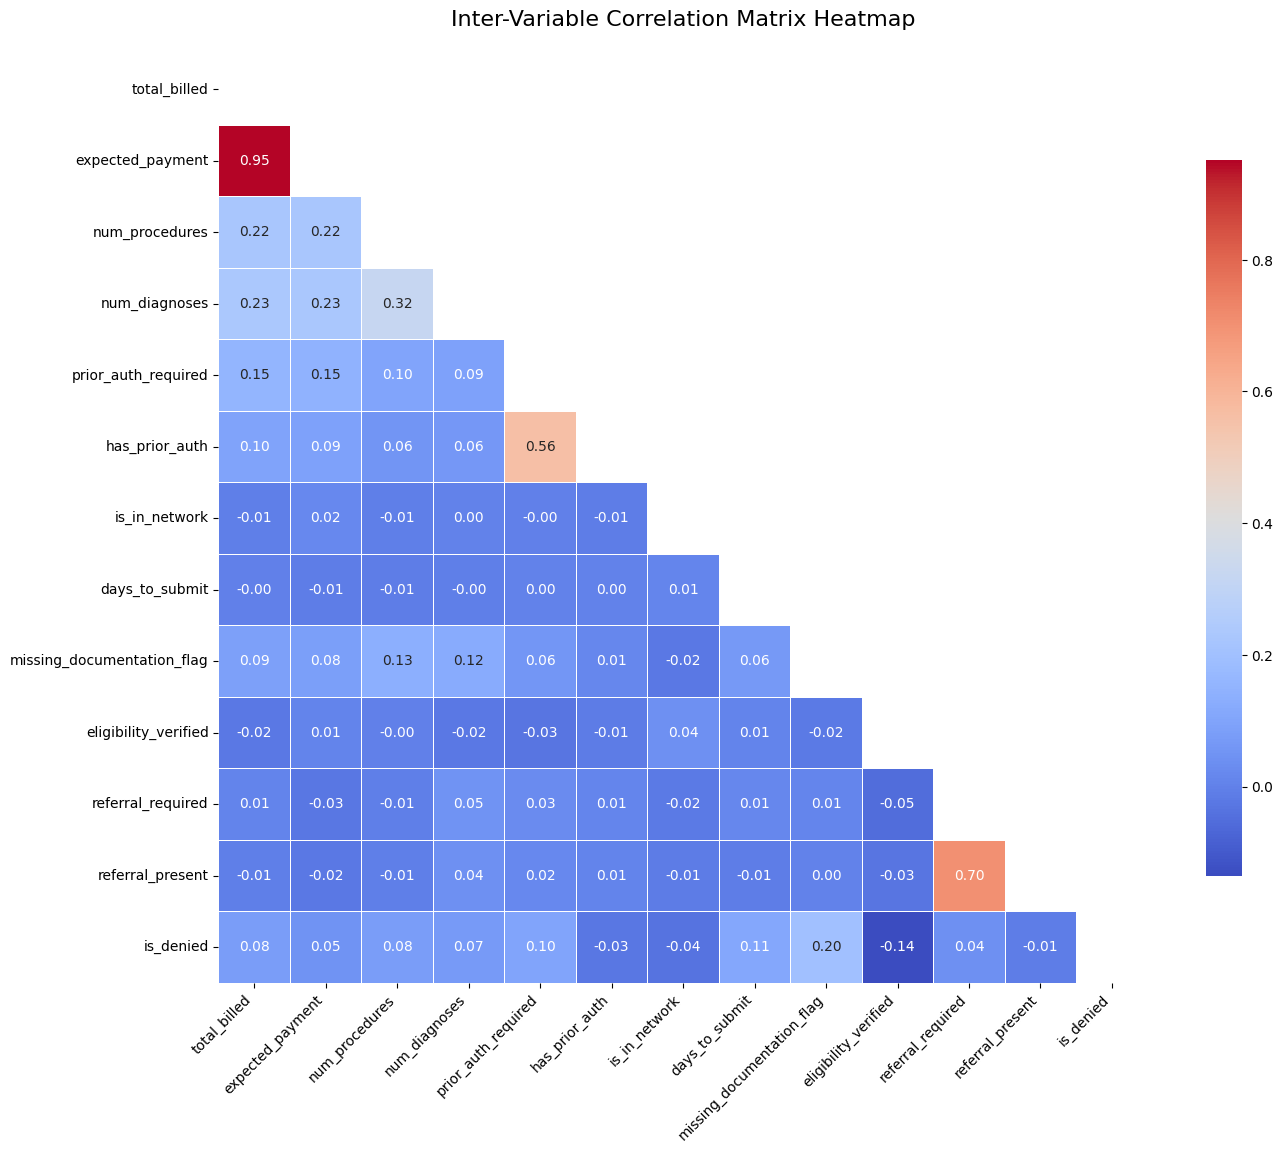

In [ ]:

# 1. Convert boolean/flag columns to numeric (0 or 1)
bool_cols = [
    'prior_auth_required', 'has_prior_auth', 'is_in_network',
    'missing_documentation_flag', 'eligibility_verified',
    'referral_required', 'referral_present', 'is_denied'
]
for col in bool_cols:
    if col in claim_h.columns:
        claim_h[col] = claim_h[col].astype(int)

# 2. Drop unique identifier and non-predictive columns
cols_to_drop = ['claim_id', 'payer_id', 'split']
numeric_df = claim_h.drop(columns=[c for c in cols_to_drop if c in claim_h.columns])

# 3. One-hot encode categorical variables to include them in the correlation
categorical_cols = ['payer_type', 'visit_type', 'service_month']
numeric_df = pd.get_dummies(numeric_df, columns=categorical_cols, drop_first=True)

# 4. Filter to keep only numeric columns just in case
numeric_df = numeric_df.select_dtypes(include=[np.number])

# 5. Compute the full correlation matrix
corr_matrix = numeric_df.corr()

# =========================================================================
# i) Check the correlation with the output variable (is_denied)
# =========================================================================
print("--- Correlation with 'is_denied' (Sorted) ---")
denied_corr = corr_matrix['is_denied'].sort_values(ascending=False)
print(denied_corr)

# =========================================================================
# ii) Check the correlation within the variables (Heatmap Visual)
# =========================================================================
# Setup the plot using subplots to control layout size
fig, ax = plt.subplots(figsize=(14, 12))

# Generate a mask for the upper triangle (optional, makes it cleaner to read)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Shows the correlation coefficients
    fmt=".2f",          # Rounds to 2 decimal places
    cmap="coolwarm",    # Blue for negative, Red for positive correlations
    square=True,
    ax=ax,
    linewidths=.5,
    cbar_kws={"shrink": .7}
)

ax.set_title("Inter-Variable Correlation Matrix Heatmap", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()


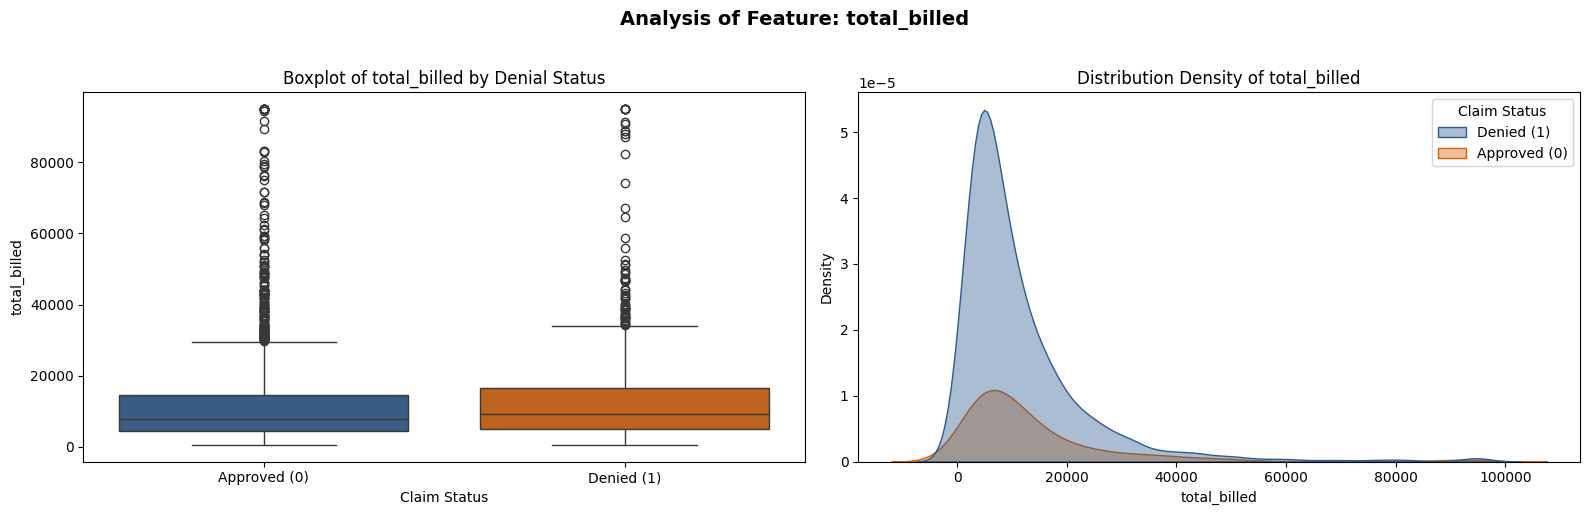

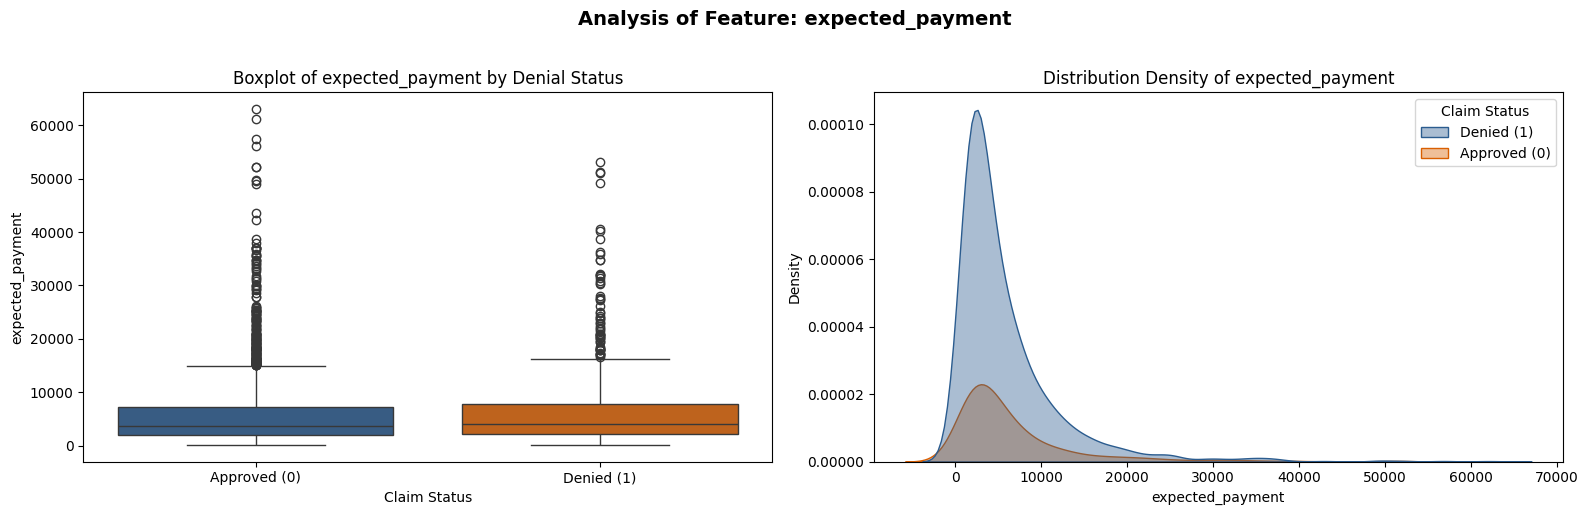

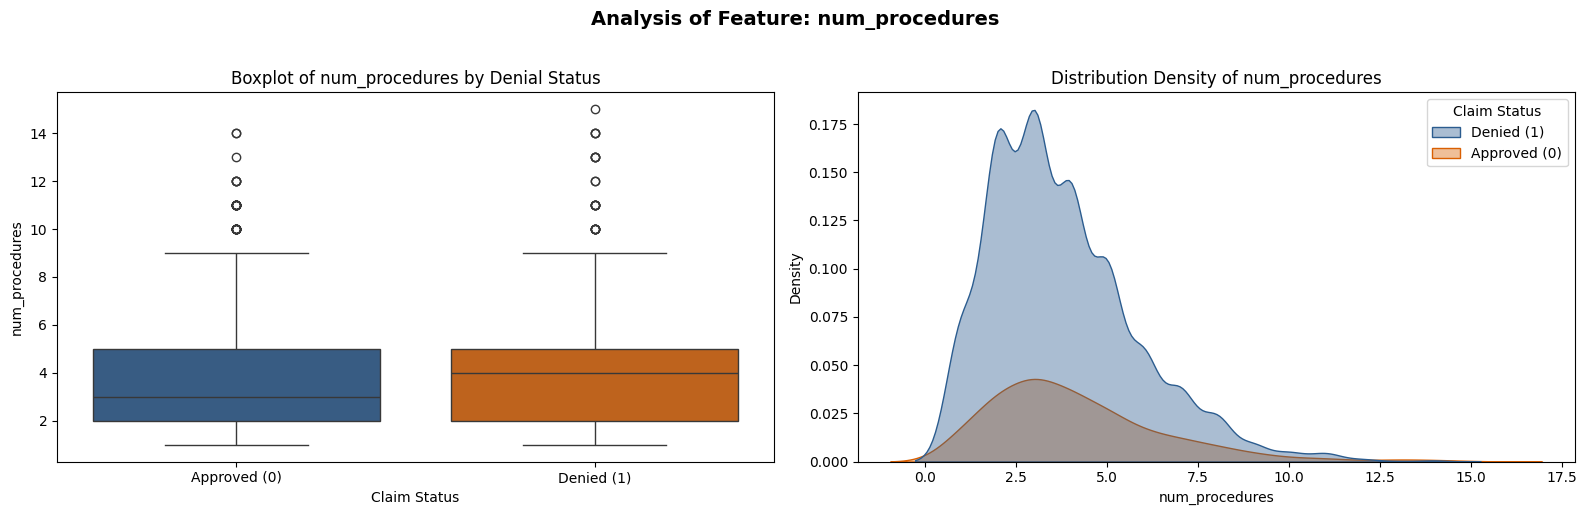

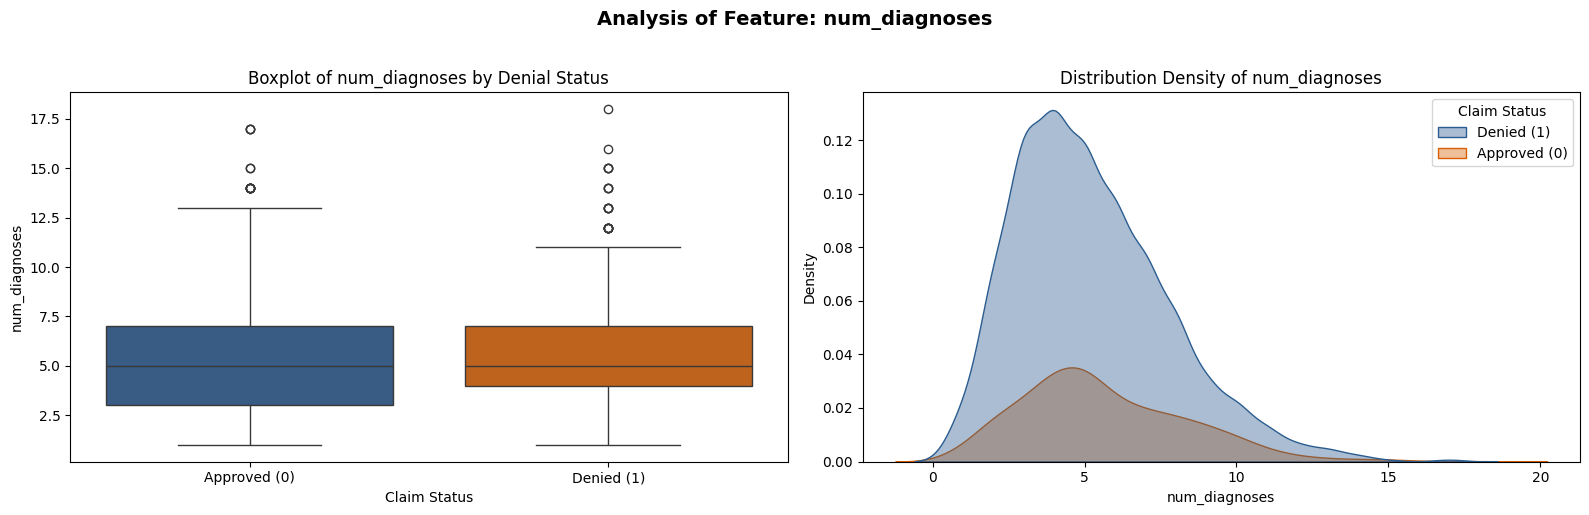

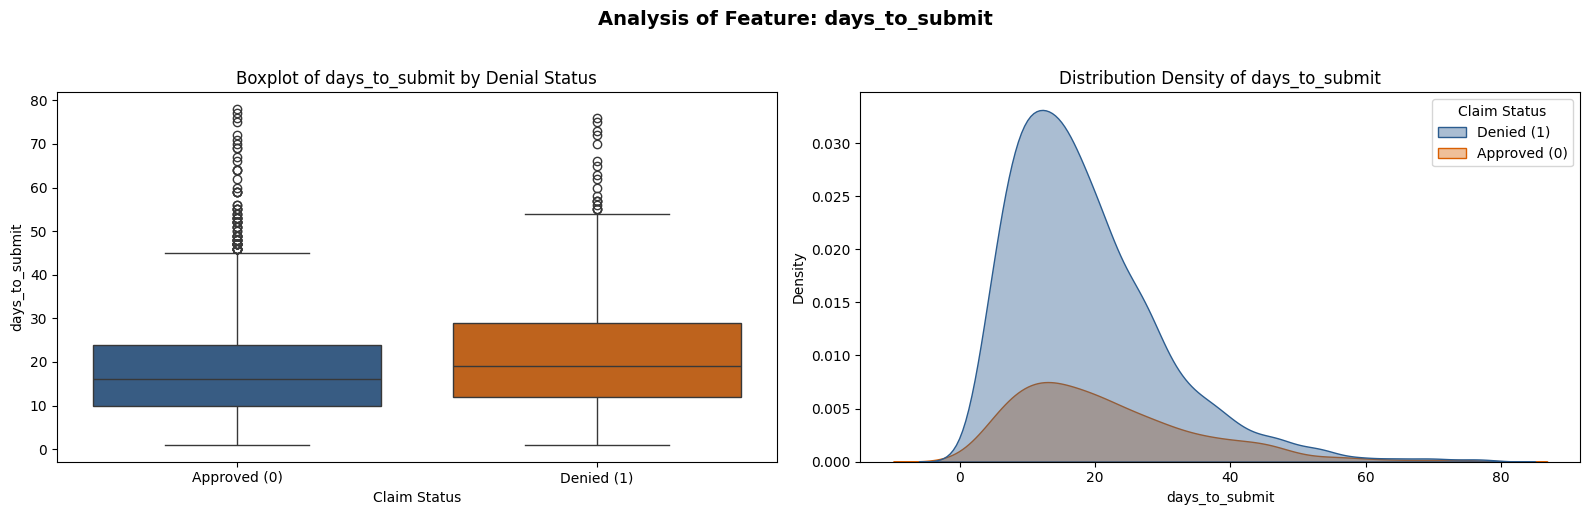

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'claim_h' is your original DataFrame
num_cols = ['total_billed', 'expected_payment', 'num_procedures', 'num_diagnoses', 'days_to_submit']

for col in num_cols:
    if col in claim_h.columns:
        # Create a figure with 2 subplots side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # --- Plot 1: Boxplot (Warning free) ---
        sns.boxplot(
            data=claim_h,
            x='is_denied',
            y=col,
            hue='is_denied',        # Fixes the palette/hue deprecation warning
            palette=['#2b5c8f', '#d95f02'],
            legend=False,
            ax=axes[0]
        )
        axes[0].set_title(f'Boxplot of {col} by Denial Status', fontsize=12)
        axes[0].set_xticks([0, 1])  # Fixes the UserWarning by locking the tick positions
        axes[0].set_xticklabels(['Approved (0)', 'Denied (1)'])
        axes[0].set_xlabel('Claim Status')

        # --- Plot 2: KDE Plot (To look at the distribution shape/overlap) ---
        sns.kdeplot(
            data=claim_h,
            x=col,
            hue='is_denied',
            fill=True,
            palette=['#2b5c8f', '#d95f02'],
            alpha=0.4,
            ax=axes[1]
        )
        axes[1].set_title(f'Distribution Density of {col}', fontsize=12)
        axes[1].set_xlabel(col)

        # Fix legend labels dynamically
        legend = axes[1].get_legend()
        if legend:
            legend.set_title("Claim Status")
            for text, label in zip(legend.get_texts(), ['Denied (1)', 'Approved (0)']):
                text.set_text(label)

        plt.suptitle(f'Analysis of Feature: {col}', fontsize=14, weight='bold', y=1.02)
        plt.tight_layout()
        plt.show()


--- Denial Distribution for payer_type ---
is_denied           Approved (%)  Denied (%)
payer_type                                  
BCBS                       78.72       21.28
Commercial                 85.07       14.93
Medicaid MCO               69.45       30.55
Medicare Advantage         74.55       25.45


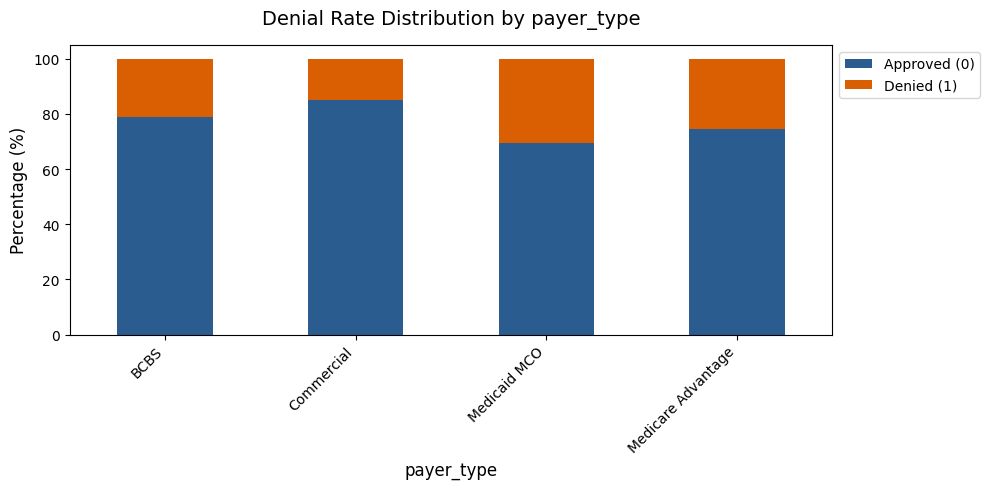


--- Denial Distribution for visit_type ---
is_denied    Approved (%)  Denied (%)
visit_type                           
Emergency           81.72       18.28
Inpatient           69.43       30.57
Observation         81.87       18.13
Outpatient          80.03       19.97


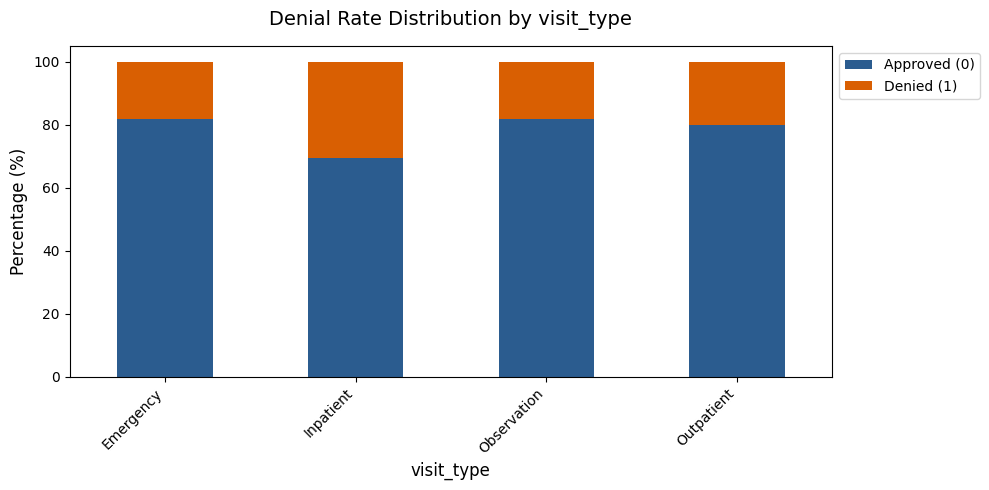


--- Denial Distribution for service_month ---
is_denied      Approved (%)  Denied (%)
service_month                          
2024-01               75.18       24.82
2024-02               80.00       20.00
2024-03               77.78       22.22
2024-04               80.92       19.08
2024-05               80.00       20.00
2024-06               83.27       16.73
2024-07               76.95       23.05
2024-08               77.04       22.96
2024-09               81.64       18.36
2024-10               80.21       19.79
2024-11               73.96       26.04
2024-12               74.10       25.90


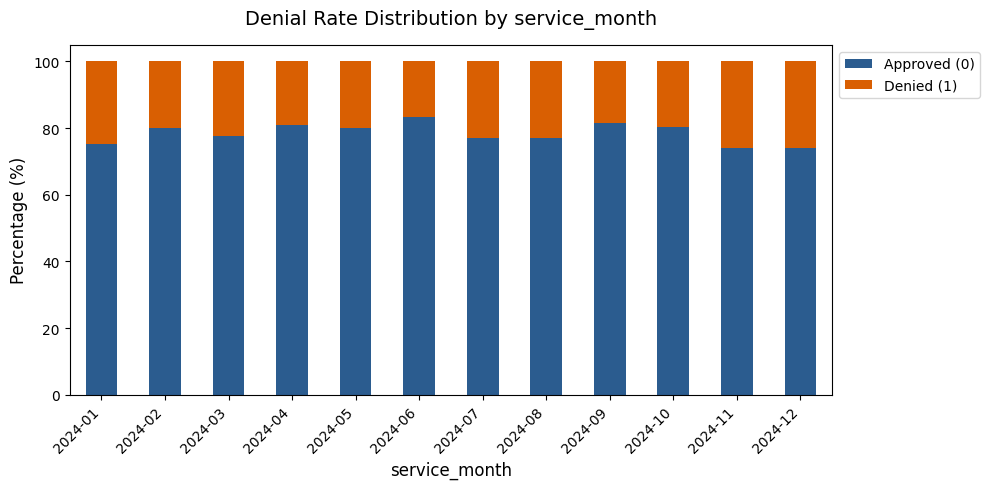

In [ ]:


# Assuming 'claim_h' is your original DataFrame

categorical_cols = ['payer_type', 'visit_type', 'service_month']

# Loop through each categorical column to create a distribution plot against 'is_denied'
for col in categorical_cols:
    if col in claim_h.columns:

        # 1. Calculate percentage distributions for the text summary
        print(f"\n--- Denial Distribution for {col} ---")
        dist_df = pd.crosstab(claim_h[col], claim_h['is_denied'], normalize='index') * 100
        print(dist_df.round(2).rename(columns={0: 'Approved (%)', 1: 'Denied (%)'}))

        # 2. Plotting the distribution
        plt.figure(figsize=(10, 5))

        # Using a normalized stacked bar plot to compare proportions directly
        # If your data is heavily imbalanced, standard countplots can hide variations
        df_pct = claim_h.groupby(col)['is_denied'].value_counts(normalize=True).unstack() * 100

        df_pct.plot(
            kind='bar',
            stacked=True,
            color=['#2b5c8f', '#d95f02'],  # Clean corporate blue vs sharp denial orange/red
            ax=plt.gca()
        )

        plt.title(f'Denial Rate Distribution by {col}', fontsize=14, pad=15)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Percentage (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend(['Approved (0)', 'Denied (1)'], loc='upper left', bbox_to_anchor=(1, 1))

        plt.tight_layout()
        plt.show()

In [ ]:
# Combine your passthrough boolean columns and the target
boolean_cols = ['prior_auth_required', 'has_prior_auth', 'is_in_network', 'missing_documentation_flag', 'eligibility_verified', 'referral_required', 'referral_present']

for col in boolean_cols:
    print(f"\n--- Distribution for {col} against Rejections ---")
    # normalize='index' converts numbers into percentages across the row
    ct = pd.crosstab(claim_h[col], claim_h['is_denied'], normalize='index') * 100
    print(ct.round(2).rename(columns={0: 'Approved (%)', 1: 'Denied (%)'}))


--- Distribution for prior_auth_required against Rejections ---
is_denied            Approved (%)  Denied (%)
prior_auth_required                          
0                           81.60       18.40
1                           73.19       26.81

--- Distribution for has_prior_auth against Rejections ---
is_denied       Approved (%)  Denied (%)
has_prior_auth                          
0                      77.45       22.55
1                      79.87       20.13

--- Distribution for is_in_network against Rejections ---
is_denied      Approved (%)  Denied (%)
is_in_network                          
0                     75.13       24.87
1                     79.14       20.86

--- Distribution for missing_documentation_flag against Rejections ---
is_denied                   Approved (%)  Denied (%)
missing_documentation_flag                          
0                                  82.36       17.64
1                                  61.42       38.58

--- Distribution for el

In [ ]:
#checking null values
claim_h.isnull().sum()

,0
claim_id,0
payer_id,0
payer_type,0
visit_type,0
total_billed,0
expected_payment,0
num_procedures,0
num_diagnoses,0
prior_auth_required,0
has_prior_auth,0


Splitting the data for train/test/validation

In [ ]:
# Create the new feature (adding a tiny epsilon to avoid division by zero errors)
#claim_h['payment_to_bill_ratio'] = claim_h['expected_payment'] / (claim_h['total_billed'] + 1e-5)

train_df = claim_h[claim_h['split'] == 'train']
val_df = claim_h[claim_h['split'] == 'validation']
test_df = claim_h[claim_h['split'] == 'test']


In [ ]:
ignore_cols = ['claim_id', 'payer_id', 'split', 'is_denied']

X_train = train_df.drop(columns=ignore_cols, errors='ignore')
y_train = train_df['is_denied']

X_val = val_df.drop(columns=ignore_cols, errors='ignore')
y_val = val_df['is_denied']

X_test = test_df.drop(columns=ignore_cols, errors='ignore')
y_test = test_df['is_denied']

Standardisation of data

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_cols = ['total_billed', 'expected_payment', 'num_procedures', 'num_diagnoses', 'days_to_submit']
categorical_cols = ['payer_type', 'visit_type', 'service_month']
passthrough_cols = ['prior_auth_required', 'has_prior_auth', 'is_in_network', 'missing_documentation_flag', 'eligibility_verified', 'referral_required', 'referral_present']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('pass', 'passthrough', passthrough_cols)
    ]
)

In [ ]:
# =========================================================================
# 3. Fit on TRAIN and transform Val / Test (Prevents Data Leakage!)
# =========================================================================
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Logistic regression Model (Testing)

In [ ]:

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_proc, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# Evaluate on Validation Set (for tuning if needed)
y_val_pred = log_reg.predict(X_val_proc)
y_val_proba = log_reg.predict_proba(X_val_proc)[:, 1]

Evaluation(Test and Validation)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print("--- VALIDATION SET PERFORMANCE ---")
print(classification_report(y_val, y_val_pred))
print(f"Validation ROC-AUC: {roc_auc_score(y_val, y_val_proba):.4f}\n")

--- VALIDATION SET PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.89      0.58      0.70       436
           1       0.28      0.69      0.40       103

    accuracy                           0.60       539
   macro avg       0.58      0.63      0.55       539
weighted avg       0.77      0.60      0.64       539

Validation ROC-AUC: 0.6785



In [ ]:
# Evaluate on Test Set (Final evaluation)
y_test_pred = log_reg.predict(X_test_proc)
y_test_proba = log_reg.predict_proba(X_test_proc)[:, 1]

print("--- TEST SET PERFORMANCE ---")
print(classification_report(y_test, y_test_pred))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

--- TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.83      0.56      0.67       399
           1       0.35      0.66      0.45       140

    accuracy                           0.59       539
   macro avg       0.59      0.61      0.56       539
weighted avg       0.70      0.59      0.61       539

Test ROC-AUC: 0.6784


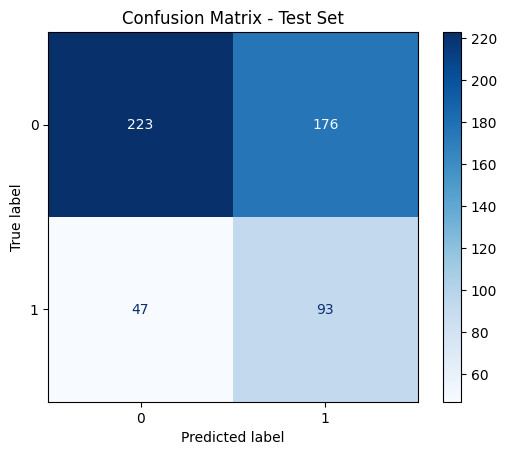

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# 2. Display the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap=plt.cm.Blues)

# 3. Show the plot
plt.title("Confusion Matrix - Test Set")
plt.show()

--- PRECISION AND RECALL DISTRIBUTION BY 20 BUCKETS ---
Prediction Score Bucket  Total Claims  Actual Denials  Precision  Recall Contribution
              0.00-0.05             0               0     0.0000               0.0000
              0.05-0.10             0               0     0.0000               0.0000
              0.10-0.15             0               0     0.0000               0.0000
              0.15-0.20             7               0     0.0000               0.0000
              0.20-0.25            22               4     0.1818               0.0286
              0.25-0.30            41               6     0.1463               0.0429
              0.30-0.35            51               5     0.0980               0.0357
              0.35-0.40            49               7     0.1429               0.0500
              0.40-0.45            53               9     0.1698               0.0643
              0.45-0.50            47              16     0.3404               0.114

/tmp/ipykernel_646/3295810665.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(summary_table['Prediction Score Bucket'], rotation=45, ha='right')


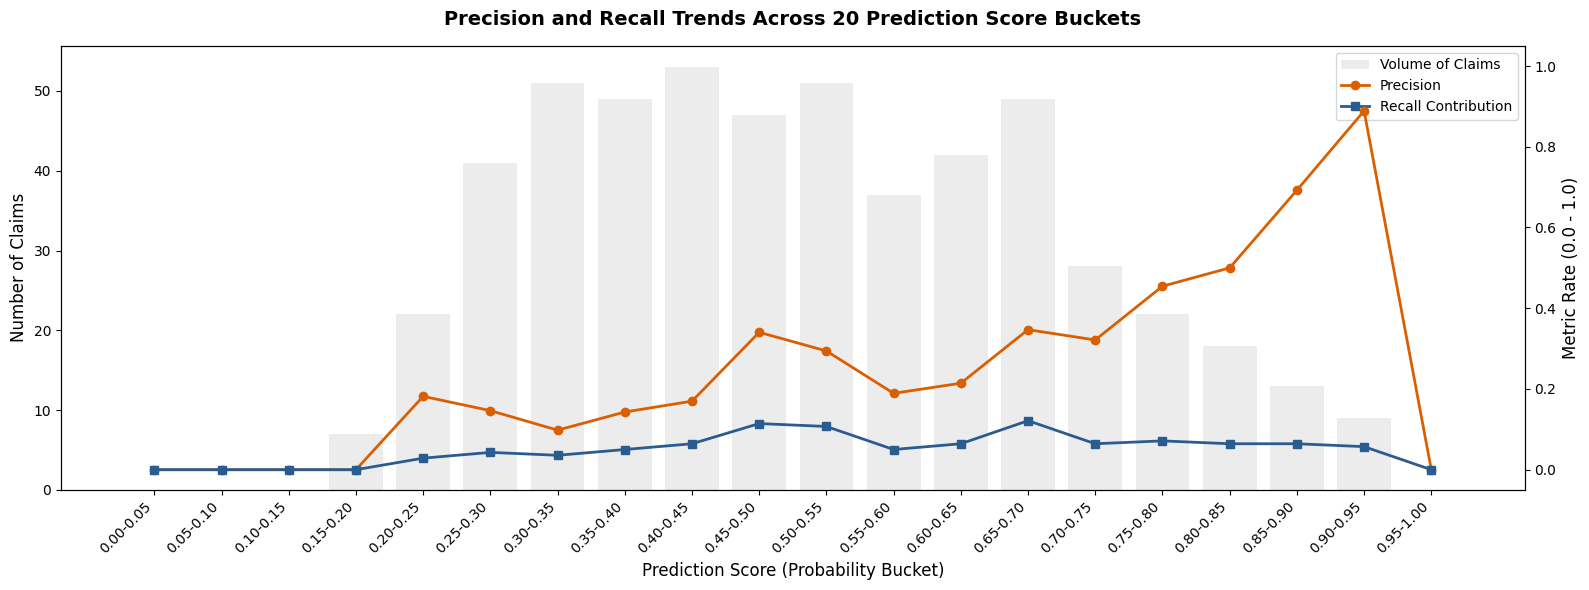

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a temporary DataFrame with actual targets and prediction probabilities
bucket_df = pd.DataFrame({
    'actual': y_test,
    'prob': y_test_proba
})

# 2. Define the 20 bins from 0.0 to 1.0 (21 endpoints create 20 intervals)
bins = np.linspace(0, 1, 21)
labels = [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(20)]

# Assign each prediction probability to one of the 20 buckets
bucket_df['bucket'] = pd.cut(bucket_df['prob'], bins=bins, labels=labels, include_lowest=True)

# 3. Calculate metrics for each bucket
# Total actual positives in the entire test set (needed for recall baseline)
total_actual_positives = (bucket_df['actual'] == 1).sum()

bucket_results = []

for label in labels:
    subset = bucket_df[bucket_df['bucket'] == label]
    total_predicted_in_bucket = len(subset)
    true_positives_in_bucket = (subset['actual'] == 1).sum()

    # Precision within this specific bucket
    precision = true_positives_in_bucket / total_predicted_in_bucket if total_predicted_in_bucket > 0 else 0.0

    # Recall (contribution of this bucket to total actual denials)
    recall = true_positives_in_bucket / total_actual_positives if total_actual_positives > 0 else 0.0

    bucket_results.append({
        'Prediction Score Bucket': label,
        'Total Claims': total_predicted_in_bucket,
        'Actual Denials': true_positives_in_bucket,
        'Precision': round(precision, 4),
        'Recall Contribution': round(recall, 4)
    })

# Convert results to a DataFrame
summary_table = pd.DataFrame(bucket_results)

print("--- PRECISION AND RECALL DISTRIBUTION BY 20 BUCKETS ---")
print(summary_table.to_string(index=False))

# =========================================================================
# Visualizing the 20-bucket distribution
# =========================================================================
fig, ax1 = plt.subplots(figsize=(16, 6))

# Bar chart for Total Claims in each bucket
ax1.bar(summary_table['Prediction Score Bucket'], summary_table['Total Claims'], color='#e0e0e0', alpha=0.6, label='Volume of Claims')
ax1.set_xlabel('Prediction Score (Probability Bucket)', fontsize=12)
ax1.set_ylabel('Number of Claims', fontsize=12)
ax1.set_xticklabels(summary_table['Prediction Score Bucket'], rotation=45, ha='right')
ax1.tick_params(axis='y')

# Line chart for Precision and Recall on a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(summary_table['Prediction Score Bucket'], summary_table['Precision'], color='#d95f02', marker='o', linewidth=2, label='Precision')
ax2.plot(summary_table['Prediction Score Bucket'], summary_table['Recall Contribution'], color='#2b5c8f', marker='s', linewidth=2, label='Recall Contribution')
ax2.set_ylabel('Metric Rate (0.0 - 1.0)', fontsize=12)
ax2.set_ylim(-0.05, 1.05)
ax2.tick_params(axis='y')

# Formatting and Legend
plt.title('Precision and Recall Trends Across 20 Prediction Score Buckets', fontsize=14, weight='bold', pad=15)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
#not required step

def assign_label(prob):
  if prob >= 0.85:
    return "High"
  elif prob >= 0.5:
    return "Medium"
  else:
    return "Low"
  return
final_test_df = pd.DataFrame({'Actual_Denial': y_test.values, 'Prediction_probability': y_test_proba})
final_test_df['prediction_label'] = final_test_df['Prediction_probability'].apply(assign_label)


final_test_df.head()

cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(encoded_cat_cols) + list(passthrough_cols)

X_test_proc_df = pd.DataFrame(X_test_proc, columns=all_feature_names)

coefficients = log_reg.coef_[0]
contribution_matrix = X_test_proc_df.values * coefficients
contribution_matrix

import pandas as pd

# 1. Create the contribution DataFrame
contribution_df = pd.DataFrame(contribution_matrix, columns=all_feature_names)

# 2. Initialize an empty list to store the strings *before* the loop starts
risk_drivers = []

# 3. Corrected loop: added (), fixed variable unpacking (idx, row)
for idx, row in contribution_df.iterrows():
    # Sort features by their positive contribution descending
    sorted_features = row.sort_values(ascending=False)

    # Take the top 3 feature names
    top_3_names = sorted_features.index[:3]

    # Combine them into a single string separated by commas
    drivers_string = ", ".join(top_3_names)

    # Append this row's string to our master list
    risk_drivers.append(drivers_string)

# 4. Create the final DataFrame ONCE after the loop is completely finished
claims_explanation_df = pd.DataFrame({
    'Actual_Denial': y_test.values,
    'Risk_Score': y_test_proba,
    'Top_Drivers': risk_drivers  # Pass the complete list of strings here
})

# Display the final result
print(claims_explanation_df.head())

   Actual_Denial  Risk_Score  \
0              0    0.390480   
1              0    0.307801   
2              1    0.315113   
3              1    0.719855   
4              0    0.449735   

                                         Top_Drivers  
0  prior_auth_required, referral_required, expect...  
1  prior_auth_required, referral_required, expect...  
2  days_to_submit, expected_payment, payer_type_M...  
3  prior_auth_required, visit_type_Inpatient, ref...  
4  days_to_submit, expected_payment, payer_type_M...  


TEST DATA

In [ ]:
import pandas as pd
import numpy as np

current_claim = pd.read_csv('/content/drive/MyDrive/Classroom/current_claims.csv')
current_claim


,claim_id,payer_id,payer_type,visit_type,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,is_in_network,days_to_submit,missing_documentation_flag,eligibility_verified,referral_required,referral_present,service_month
0,CCLM-00001,P004,Commercial,Emergency,2617.41,1120.76,4,5,0,0,0,14,0,1,0,0,2025-01
1,CCLM-00002,P003,Commercial,Outpatient,3060.56,1961.11,2,4,1,1,1,32,0,1,0,0,2025-02
2,CCLM-00003,P006,Medicare Advantage,Outpatient,11345.61,4650.61,3,5,0,0,1,10,0,0,0,0,2025-01
3,CCLM-00004,P003,Commercial,Inpatient,47634.66,23640.30,5,8,1,1,0,15,0,1,0,1,2025-02
4,CCLM-00005,P008,Medicaid MCO,Outpatient,2453.93,793.59,2,1,0,0,1,29,0,1,0,0,2025-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CCLM-00496,P005,Medicare Advantage,Observation,3869.97,1321.77,2,2,0,0,1,27,0,1,0,0,2025-01
496,CCLM-00497,P001,Commercial,Observation,3740.88,2057.47,2,5,0,0,0,4,0,0,0,0,2025-02
497,CCLM-00498,P007,Medicaid MCO,Emergency,9144.16,3570.37,4,6,0,1,1,9,0,1,0,0,2025-02
498,CCLM-00499,P011,Commercial,Emergency,14296.33,7499.72,5,7,0,0,1,14,0,1,0,0,2025-02


In [ ]:
import pandas as pd

# 1. Transform the data and get probabilities
X_new_proc = preprocessor.transform(current_claim)
new_pred_prob = log_reg.predict_proba(X_new_proc)[:, 1]  # Fixed spacing around log_reg

# 2. Reconstruct column names
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(encoded_cat_cols) + list(passthrough_cols)

X_new_proc_df = pd.DataFrame(X_new_proc, columns=all_feature_names)

# 3. Calculate contributions
coefficents = log_reg.coef_[0]
contribution_matrix = X_new_proc_df.values * coefficents
# FIX: Changed 'all_features_names' to 'all_feature_names' to match step 2
contribution_df = pd.DataFrame(contribution_matrix, columns=all_feature_names)

# 4. Extract top 3 features
# FIX: Changed 'risk_driver = []' to 'risk_drivers = []' so it matches what you append to
risk_drivers = []

# FIX: iteration unpacking must be (idx, row). 'row' captures index, 'values' captures data
for idx, row in contribution_df.iterrows():
    sorted_features = row.sort_values(ascending=False)
    top_3_names = sorted_features.index[:3]
    drivers_string = ", ".join(top_3_names)  # Added a space after the comma for readability
    risk_drivers.append(drivers_string)

# 5. Assign Tiers
def assign_hml_tier(prob):
    if prob >= 0.85:
        return 'High'
    elif prob >= 0.50:
        return 'Medium'
    else:
        return 'Low'

# 6. Build prediction frame
preditions_df = pd.DataFrame({
    'High_score': new_pred_prob,
    'Risk_Tier': [assign_hml_tier(p) for p in new_pred_prob],
    'Top_drivers': risk_drivers
})

# FIX: Changed 'predictions_df' to 'preditions_df' to match the variable created above
final_output_df = pd.concat([current_claim.reset_index(drop=True), preditions_df], axis=1)



print("--- NEW DATA PREDICTIONS & EXPLANATIONS COMPLETE ---")
# FIX: Updated keys to match exactly what exists in final_output_df ('High_score' and 'Top_drivers')
print(final_output_df[['High_score', 'Risk_Tier', 'Top_drivers']].head(10))

--- NEW DATA PREDICTIONS & EXPLANATIONS COMPLETE ---
   High_score Risk_Tier                                        Top_drivers
0    0.329046       Low  expected_payment, payer_type_Medicare Advantag...
1    0.365738       Low  prior_auth_required, days_to_submit, expected_...
2    0.619022    Medium  payer_type_Medicare Advantage, expected_paymen...
3    0.418818       Low  prior_auth_required, total_billed, visit_type_...
4    0.538249    Medium  payer_type_Medicaid MCO, days_to_submit, expec...
5    0.691125    Medium  missing_documentation_flag, expected_payment, ...
6    0.429833       Low    num_diagnoses, expected_payment, num_procedures
7    0.204896       Low  total_billed, payer_type_Medicare Advantage, v...
8    0.474256       Low  payer_type_Medicaid MCO, expected_payment, num...
9    0.285746       Low  expected_payment, payer_type_Medicare Advantag...


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


LLM resonse

In [ ]:
import pandas as pd
import numpy as np

# 1. Transform the data and get probabilities
X_new_proc = preprocessor.transform(current_claim)

# Handle sparse matrix output safely if preprocessor outputs scipy sparse matrix
if hasattr(X_new_proc, "toarray"):
    X_new_proc_dense = X_new_proc.toarray()
else:
    X_new_proc_dense = X_new_proc

new_pred_prob = log_reg.predict_proba(X_new_proc_dense)[:, 1]

# 2. Reconstruct column names
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(encoded_cat_cols) + list(passthrough_cols)

X_new_proc_df = pd.DataFrame(X_new_proc_dense, columns=all_feature_names)

# 3. Calculate contributions
coefficents = log_reg.coef_[0]
contribution_matrix = X_new_proc_df.values * coefficents
contribution_df = pd.DataFrame(contribution_matrix, columns=all_feature_names)

raw_claims_reset = current_claim.reset_index(drop=True)

# 4. Extract top 3 features (Synchronized row-by-row loop)
risk_drivers = []
prompt_context_list = []

for idx, row in contribution_df.iterrows():
    # Sort features for this specific row in descending order
    sorted_features = row.sort_values(ascending=False)

    # Extract simple comma-separated top 3 names
    top_3_names = sorted_features.index[:3]
    drivers_string = ", ".join(top_3_names)
    risk_drivers.append(drivers_string)

    # --- FIXED: Moved row_details building INSIDE the main loop ---
    row_details = []

    # Process only the top 3 features for this specific row
    for rank, (feat_name, impact_val) in enumerate(list(sorted_features.items())[:3], 1):
        raw_val = "N/A" # Default fallback

        if feat_name in raw_claims_reset.columns:
            raw_val = raw_claims_reset.loc[idx, feat_name]
        else:
            # Check if it's a One-Hot-Encoded column (e.g., 'payer_Medicare')
            for orig_col in categorical_cols:
                if feat_name.startswith(orig_col) and X_new_proc_df.loc[idx, feat_name] == 1:
                    raw_val = feat_name.split(orig_col + "_")[-1] # Extracts just the class name
                    break # Stop searching once found

        row_details.append(f"{rank}. {feat_name} (Impact: +{impact_val:.2f} | Raw: {raw_val})")

    # Appends exactly ONE joined string per loop iteration, matching array lengths perfectly
    prompt_context_list.append(" | ".join(row_details))


# 5. Assign Tiers
def assign_hml_tier(prob):
    if prob >= 0.85:
        return 'High'
    elif prob >= 0.50:
        return 'Medium'
    else:
        return 'Low'

# 6. Build prediction frame
# Note: Uncommented 'Prompt_Context' since lengths are now aligned!
predictions_df = pd.DataFrame({
    'High_score': new_pred_prob,
    'Risk_Tier': [assign_hml_tier(p) for p in new_pred_prob],
    'Top_drivers': risk_drivers,
    'Prompt_Context': prompt_context_list
})

# Concatenate back to original features frame
final_output_df = pd.concat([raw_claims_reset, predictions_df], axis=1)

print("--- NEW DATA PREDICTIONS & EXPLANATIONS COMPLETE ---")
print(final_output_df[['High_score', 'Risk_Tier', 'Top_drivers', 'Prompt_Context']].head(10))

--- NEW DATA PREDICTIONS & EXPLANATIONS COMPLETE ---
   High_score Risk_Tier                                        Top_drivers  \
0    0.329046       Low  expected_payment, payer_type_Medicare Advantag...   
1    0.365738       Low  prior_auth_required, days_to_submit, expected_...   
2    0.619022    Medium  payer_type_Medicare Advantage, expected_paymen...   
3    0.418818       Low  prior_auth_required, total_billed, visit_type_...   
4    0.538249    Medium  payer_type_Medicaid MCO, days_to_submit, expec...   
5    0.691125    Medium  missing_documentation_flag, expected_payment, ...   
6    0.429833       Low    num_diagnoses, expected_payment, num_procedures   
7    0.204896       Low  total_billed, payer_type_Medicare Advantage, v...   
8    0.474256       Low  payer_type_Medicaid MCO, expected_payment, num...   
9    0.285746       Low  expected_payment, payer_type_Medicare Advantag...   

                                      Prompt_Context  
0  1. expected_payment (Impact: +

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
final_output_df[['claim_id','High_score', 'Risk_Tier', 'Top_drivers','Prompt_Context']].sort_values(by="High_score", ascending=False).head(10)


,claim_id,High_score,Risk_Tier,Top_drivers,Prompt_Context
81,CCLM-00082,0.948655,High,"missing_documentation_flag, total_billed, visi...",1. missing_documentation_flag (Impact: +1.08 |...
27,CCLM-00028,0.917283,High,"missing_documentation_flag, payer_type_Medicai...",1. missing_documentation_flag (Impact: +1.08 |...
135,CCLM-00136,0.901273,High,"total_billed, missing_documentation_flag, prio...",1. total_billed (Impact: +1.17 | Raw: 95000.0)...
445,CCLM-00446,0.899789,High,"missing_documentation_flag, prior_auth_require...",1. missing_documentation_flag (Impact: +1.08 |...
279,CCLM-00280,0.886099,High,"missing_documentation_flag, prior_auth_require...",1. missing_documentation_flag (Impact: +1.08 |...
86,CCLM-00087,0.885892,High,"missing_documentation_flag, days_to_submit, to...",1. missing_documentation_flag (Impact: +1.08 |...
278,CCLM-00279,0.881699,High,"missing_documentation_flag, prior_auth_require...",1. missing_documentation_flag (Impact: +1.08 |...
134,CCLM-00135,0.864253,High,"missing_documentation_flag, total_billed, days...",1. missing_documentation_flag (Impact: +1.08 |...
48,CCLM-00049,0.847643,Medium,"missing_documentation_flag, prior_auth_require...",1. missing_documentation_flag (Impact: +1.08 |...
371,CCLM-00372,0.844730,Medium,"missing_documentation_flag, prior_auth_require...",1. missing_documentation_flag (Impact: +1.08 |...


In [ ]:
final_output_df.to_csv('final_data.csv')

Prompt

You are an expert healthcare risk auditor. Your task is to summarize claim risk using the provided data into a layman-friendly explanation of exactly 2 lines.

Line 1: State the risk score, tier, and a brief, plain-English summary of why the claim is a risk based on its top features (using their raw/scaled values).
Line 2: Provide a direct, actionable next step on what needs to be done to resolve or audit this specific case.

Do not include any introductory or concluding text. Strictly output exactly 2 lines.